In [1]:
import psutil
import platform
import os
env_name = os.environ.get('CONDA_DEFAULT_ENV')
print("当前 conda 环境名：", env_name)
print(platform.system()) # 操作系统名称
print(platform.release()) # 操作系统版本
print(platform.machine()) # 计算机架构
print(platform.processor()) # 处理器类型
# CPU 信息
print(psutil.cpu_count()) # CPU 核数
print(psutil.cpu_freq()) # CPU 频率
# 内存信息
print(psutil.virtual_memory()) # 内存总量、可用内存、已用内存等

当前 conda 环境名： dl_env
Windows
10
AMD64
Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
16
scpufreq(current=1900.0, min=0.0, max=1900.0)
svmem(total=16794320896, available=2320547840, percent=86.2, used=14473773056, free=2320547840)


In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [3]:
def xyplot(x_vals, y_vals, name):
    plt.figure(figsize=(5, 2.5))
    plt.plot(x_vals.detach().numpy(), y_vals.detach().numpy())
    plt.xlabel('x')
    plt.ylabel(name + '(x)')
    plt.show()

# 多层感知机
## 理论计算

1. 非线性激活函数的重要性：假设一个具有单隐藏层的多层感知机，输入为x，隐藏层没有激活函数（即线性激活），表达为h=W1x+b1，输出层为o=W2h+b2 。请通过代数推导证明，该网络等价于一个单层神经网络，并写出等价后的权重矩阵W′和偏置向量b′。

输出 $O \in \mathbb{R}^{n \times q}$ 的计算为：
$$
H = XW_h + b_h,
$$
$$
O = HW_o + b_o,
$$
代入得
$$
O = (XW_1 + b_1)W_2 + b_2 = X(W_1W_2) + (b_1W_2 + b_2)
$$
因此，等价后的权重矩阵为 $W' = W_1W_2$，偏置向量为 $b' = b_1W_2 + b_2$。

2. 激活函数性质分析：写出Sigmoid(x) 和 tanh(x) 的数学表达式，并推导它们的导数Sigmoid′(x) 和 tanh′(x) 与其函数自身的关系。

sigmoid函数可以将元素的值变换到0和1之间：
$$sigmoid(x) = \frac{1}{1+e^{-x}} = \frac{e^{x}}{e^{x}+1}$$

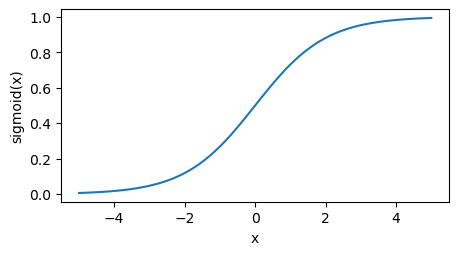

In [4]:
x = torch.linspace(-5, 5, 100, requires_grad=True)
y = torch.sigmoid(x)
xyplot(x, y, 'sigmoid')

根据链式法则，sigmoid函数的导数可以表示为：
$$sigmoid'\,(x) = sigmoid(x) (1 - sigmoid(x)).$$

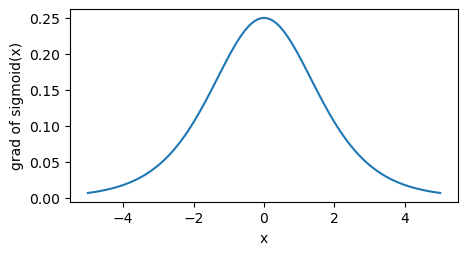

In [5]:
y.sum().backward()
xyplot(x, x.grad, 'grad of sigmoid')

tanh（双曲正切）函数可以将元素的值变换到-1和1之间：
$$\tanh(x) = \frac{1 - e^{-2x}}{1 + e^{-2x}} = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}$$
实际上，tanh函数是sigmoid函数的一个线性变换：$\tan h(x) = 2 \mathrm{sigmoid}(2x) - 1$

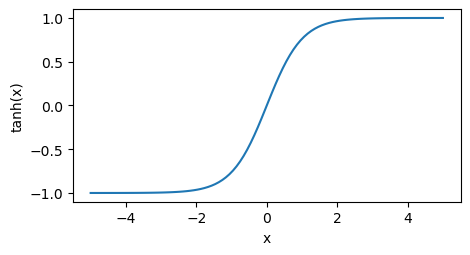

In [6]:
y = x.tanh()
xyplot(x, y, 'tanh')

依据链式法则，tanh函数的导数为：
$$\tanh'(x) = 1 - \tanh^2(x)$$

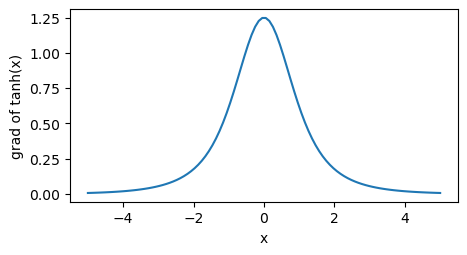

In [7]:
y.sum().backward()
xyplot(x, x.grad, 'grad of tanh')

## 编程题
不使用深度学习框架的高级API（仅使用Tensor基础算子如torch.matmul等），纯 NumPy 或 PyTorch 从零实现一个多分类（使用 Fashion-MNIST数据集）的单隐藏层MLP。实现要求：
1. 手动初始化隐藏层参数W1,b1 和输出层参数W2,b2（提示：使用正态分布随机初始化）
2. 实现 ReLU 激活函数的前向传播：max(0,x) 。
3. 实现带有Softmax 的交叉熵损失函数。
4. 编写训练循环，通过小批量随机梯度下降（Mini-batch SGD）手动更新参数。

In [9]:
# ---------- 1. 设置随机种子（可复现） ----------
torch.manual_seed(42)

# ---------- 2. 加载 Fashion-MNIST ----------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))   # 展平为 784 维向量
])
train_set = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_set = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

batch_size = 256
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

# ---------- 3. 初始化参数 ----------
input_size = 784    # 输入维度：28×28=784
hidden_size = 256   # 隐藏层神经元数量
output_size = 10    # 输出维度：10 个类别

# 正态分布随机初始化，再乘以 0.01 使初始值较小
W1 = torch.randn(input_size, hidden_size) * 0.01
b1 = torch.zeros(hidden_size)   # 偏置初始化为 0
W2 = torch.randn(hidden_size, output_size) * 0.01
b2 = torch.zeros(output_size)   # 偏置初始化为 0

# ---------- 4. 定义激活函数和损失函数 ----------
def relu(x):
    return torch.max(x, torch.zeros_like(x))

def softmax(logits):
    #减去每行最大值，防止指数溢出
    exp_logits = torch.exp(logits - torch.max(logits, dim=1, keepdim=True)[0])  
    return exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)

def cross_entropy_loss_with_softmax(logits, y):
    """
    带 Softmax 的交叉熵损失函数
    返回: loss (标量), 以及 logits 上的梯度 dL/dlogits
    """ 
    batch_size = logits.shape[0]
    # 前向: 计算 softmax 概率
    probs = softmax(logits)                        # (batch, 10)
    # 计算交叉熵损失
    log_probs = torch.log(probs + 1e-8)            # 防止 log(0)
    loss = -log_probs[range(batch_size), y].mean() # 标量
    
    # 反向: 计算 dL/dlogits (经典结果: probs - one_hot)
    # 推导：dL/dlogits_i = p_i - y_i（y 为 one-hot 编码）
    one_hot = torch.zeros_like(probs)
    one_hot[range(batch_size), y] = 1.0
    grad_logits = (probs - one_hot) / batch_size   # 除以 batch_size 是因为 loss 已经取均值
    
    return loss, grad_logits

# ---------- 5. 超参数 ----------
lr = 0.1    # 学习率
epochs = 10 # 训练轮数

# ---------- 6. 训练循环 + 每轮测试 ----------
print ("="*60)
print ("开始训练纯手动实现的单隐藏层 MLP")
print (f"批次大小: {batch_size} | 学习率: {lr} | 训练轮数: {epochs}")
print ("="*60)
for epoch in range(epochs):
    total_loss = 0.0
    # ----- 训练一个 epoch -----
    for X, y in train_loader:
        # ----- 前向传播 -----
        # 隐藏层计算：z1 = X・W1 + b1
        z1 = torch.matmul(X, W1) + b1          # (batch, hidden_size)
        # 隐藏层激活：ReLU(z1)
        a1 = relu(z1)                         # 激活
        # 输出层计算：logits = a1・W2 + b2
        logits = torch.matmul(a1, W2) + b2     # (batch, output_size)
        # 交叉熵损失 (同时得到对 logits 的梯度)
        loss, grad_logits = cross_entropy_loss_with_softmax(logits, y)
        total_loss += loss.item()
        
        # ----- 手动反向传播（链式法则） -----
        # 1. 对 W2, b2 的梯度
        #    dL/dW2 = a1^T * grad_logits
        #    维度匹配：[256, batch] × [batch, 10] = [256, 10]
        grad_W2 = torch.matmul(a1.T, grad_logits)   # (hidden, output)
        #    ddL/db2 = sum(dL/dlogits, dim=0)
        #    偏置梯度是 batch 内所有样本梯度的和
        grad_b2 = grad_logits.sum(dim=0)            # (output,)
        
        # 2. 传播到隐藏层
        #    dL/da1 = grad_logits * W2^T
        #    维度匹配：[batch, 10] × [10, 256] = [batch, 256]
        grad_a1 = torch.matmul(grad_logits, W2.T)   # (batch, hidden)
        #    ReLU 的梯度: dL/dz1 = grad_a1 * (z1>0)
        #    负半轴梯度为 0，正半轴梯度为 1
        grad_z1 = grad_a1 * (z1 > 0).float()
        
        # 3. 对 W1, b1 的梯度
        #    dL/dW1 = X^T * grad_z1
        #    维度匹配：[784, batch] × [batch, 256] = [784, 256]
        grad_W1 = torch.matmul(X.T, grad_z1)        # (input, hidden)
        #    ddL/db1 = sum(dL/dz1, dim=0)
        #    偏置梯度是 batch 内所有样本梯度的和
        grad_b1 = grad_z1.sum(dim=0)                # (hidden,)
        
        # ----- 手动参数更新（SGD） -----
        with torch.no_grad(): # 更新参数时不需要计算梯度
            W1 -= lr * grad_W1
            b1 -= lr * grad_b1
            W2 -= lr * grad_W2
            b2 -= lr * grad_b2
    
    avg_loss = total_loss / len(train_loader)
    
    # ----- 每个 epoch 结束后在测试集上评估准确率 -----
    correct = 0
    total = 0
    with torch.no_grad():
        for X_test, y_test in test_loader:
            z1 = torch.matmul(X_test, W1) + b1
            a1 = relu(z1)
            logits_test = torch.matmul(a1, W2) + b2
            pred = torch.argmax(logits_test, dim=1) # 取概率最大的类别
            correct += (pred == y_test).sum().item()
            total += y_test.shape[0]
    test_acc = correct / total

    # 打印每个 epoch 结束后的训练损失和测试准确率
    print (f"Epoch {epoch+1:2d} | 训练损失: {avg_loss:6.4f} | 测试准确率: {test_acc:6.4f}")
    print ("="*60)


开始训练纯手动实现的单隐藏层 MLP
批次大小: 256 | 学习率: 0.1 | 训练轮数: 10
Epoch  1 | 训练损失: 1.0444 | 测试准确率: 0.7243
Epoch  2 | 训练损失: 0.5976 | 测试准确率: 0.8104
Epoch  3 | 训练损失: 0.5236 | 测试准确率: 0.8109
Epoch  4 | 训练损失: 0.4831 | 测试准确率: 0.8269
Epoch  5 | 训练损失: 0.4548 | 测试准确率: 0.7970
Epoch  6 | 训练损失: 0.4362 | 测试准确率: 0.8269
Epoch  7 | 训练损失: 0.4169 | 测试准确率: 0.8363
Epoch  8 | 训练损失: 0.4074 | 测试准确率: 0.8359
Epoch  9 | 训练损失: 0.3930 | 测试准确率: 0.8481
Epoch 10 | 训练损失: 0.3843 | 测试准确率: 0.8355


# 模型选择，权重衰减和丢弃法
## 理论计算题
1. 过拟合与欠拟合：简述训练误差（Training Error）与泛化误差（Generalization Error）的区别。当一个模型的训练误差极低，但泛化误差很高时，模型处于什么状态？应该如何通过控制模型复杂度来缓解这一现象？   

**训练误差**（training error）：模型在训练数据集上计算得到的误差。  
**泛化误差**（generalization error）：模型应用在同样从原始样本的分布中抽取的无限多数据样本时，模型误差的期望。 
当模型训练误差极低，但泛化误差很高时，称为**过拟合**。缓解过拟合的核心是**降低模型复杂度**，主要通过以下三类方法：  

(1) **参数约束（正则化）**：  
- **L1 / L2 正则化**：在损失函数中加入权重的范数惩罚项（L1范数或L2范数），限制权重的大小或稀疏性，从而降低模型复杂度。
- **权重衰减**：等价于L2正则化，在SGD更新时令权重乘以(1 - ηλ)，直接抑制权重增长。

(2) **模型结构简化**：  
- **减少网络层数或神经元数量**：直接降低模型容量。
- **参数初始化**：虽然不能直接降低复杂度，但适当的小值初始化（如正态分布乘以较小标准差）可以避免初始权重过大导致的过拟合风险；不当的初始化反而可能加剧过拟合。通常将其视为训练技巧而非复杂度控制的主要手段。

(3) **干扰优化过程（随机化正则化）**：  
- **丢弃法（Dropout）**：训练时随机丢弃部分神经元，迫使网络学习冗余表示，相当于隐式集成，提升泛化性。
- **早停（Early Stopping）**：监控验证集性能，当验证误差不再下降时提前终止训练，防止模型过度拟合训练噪声。
- **数据增强**：通过对输入施加随机变换（旋转、裁剪、加噪等），增加有效训练样本量，降低对原始数据的过拟合。


2. K 折交叉验证：阐述K 折交叉验证（K-fold Cross-Validation）的具体实施算法步骤   

在k折交叉验证中，我们把原始训练数据集分割成k个不重合的子数据集，然后我们做k次模型训练和验证。每一次，我们使用一个子数据集验证模型，并使用其他k−1个子数据集来训练模型。在这k次训练和验证中，每次用来验证模型的子数据集都不同。最后，我们对这k次训练误差和验证误差分别求平均。

## 编程题
在你实现的MLP上，加入L2 正则化和Dropout机制。
实现要求：
1. 权重衰减：在你的自定义SGD优化器中，加入权重衰减。即在计算梯度更新时，让旧权重首先乘以(1−ηλ)。
2. Dropout 从零实现：编写一个dropout_layer(X, dropout) 函数。根据传入的概率，利用随机掩码（Mask）将输入张量某些元素置0，并进行缩放。注意：通过一个布尔变量（如is_training）来控制测试时不触发Dropout 。
3. 对比实验：设计高维多项式拟合或使用极少样本训练一个复杂的MLP，绘制并对比：1) 无正则化、2) 有权重衰减、3) 有 Dropout 三种情况下的训练和验证误差曲线（LossCurve）

In [10]:
# 1.权重衰减（L2正则化）的SGD实现
def sgd(params, lr, weight_decay):
    """手动 SGD + 权重衰减"""
    with torch.no_grad():
        for param in params:
            if param.grad is None:
                continue
            # 权重衰减：W = W - η * λ * W
            if weight_decay > 0 and param.dim() >= 2:  # 通常只对权重衰减，不对偏置
                param.data -= lr * weight_decay * param.data
            # 标准梯度下降
            param.data -= lr * param.grad
            param.grad.zero_()


In [11]:

# 2. Dropout 从零实现
def dropout_layer(X, dropout, is_training=True):
    """Dropout 前向传播，测试时关闭"""
    if not is_training or dropout == 0:
        return X
    mask = (torch.rand(X.shape) > dropout).float()
    # 缩放：保证期望不变
    return mask * X / (1.0 - dropout)
dropout_rate = 0.5

# 在MLP的前向传播中使用
def net(X, is_training=True):
    X = X.reshape(-1, input_size)
    H = relu(torch.matmul(X, W1) + b1)
    if is_training and dropout_rate > 0:
        H = dropout_layer(H, dropout_rate)

    out = torch.matmul(H, W2) + b2    
    return out


In [12]:

# 3. 对比实验设置
# 取很少的训练样本，制作过拟合环境
small_train_set = torch.utils.data.Subset(train_set, range(500))
small_train_loader = torch.utils.data.DataLoader(small_train_set, batch_size=64, shuffle=True)
def train_with_regularization(train_loader, test_loader, weight_decay, dropout_rate, epochs=50, lr=0.1):
    # 初始化参数（同上）
    W1 = torch.randn(784, 256)
    W1 *= 0.01
    W1.requires_grad_()
    b1 = torch.zeros(256, requires_grad=True)
    W2 = torch.randn(256, 10)
    W2 *= 0.01
    W2.requires_grad_()
    b2 = torch.zeros(10, requires_grad=True)

    #开启梯度计算
    params = [W1, b1, W2, b2]
    for p in params:
        p.requires_grad_()
    train_losses, test_losses = [], []

    for epoch in range(epochs):
        # ----- 训练阶段 -----
        total_loss, total = 0, 0
        for X, y in train_loader:
            # 前向传播
            h = relu(torch.matmul(X, W1) + b1)
            # 训练时 dropout 开启
            if dropout_rate > 0:
                h = dropout_layer(h, dropout_rate, is_training=True)
            logits = torch.matmul(h, W2) + b2
            # 计算损失
            loss, _ = cross_entropy_loss_with_softmax(logits, y)
            # 反向传播
            loss.backward()
            # 更新参数
            sgd(params, lr, weight_decay)
            
            total_loss += loss.item() * X.shape[0]
            total += X.shape[0]
        train_losses.append(total_loss / total)
        
        # ----- 验证阶段（不启用 Dropout，无梯度）-----
        with torch.no_grad():
            val_loss, val_total = 0, 0
            for X, y in test_loader:
                h = relu(torch.matmul(X, W1) + b1)
                # 测试时 dropout 关闭
                if dropout_rate > 0:
                    h = dropout_layer(h, dropout_rate, is_training=False)
                logits = torch.matmul(h, W2) + b2
                loss, _ = cross_entropy_loss_with_softmax(logits, y)
                val_loss += loss.item() * X.shape[0]
                val_total += X.shape[0]
            test_losses.append(val_loss / val_total)
        
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}: train loss {train_losses[-1]:.4f}, test loss {test_losses[-1]:.4f}")
    return train_losses, test_losses


Epoch 10: train loss 0.9915, test loss 1.0082
Epoch 20: train loss 0.6788, test loss 0.7961
Epoch 30: train loss 0.5375, test loss 0.8339
Epoch 40: train loss 0.4354, test loss 0.6605
Epoch 50: train loss 0.2798, test loss 0.7781
Epoch 60: train loss 0.2075, test loss 0.6794
Epoch 10: train loss 1.0499, test loss 1.0231
Epoch 20: train loss 0.6917, test loss 0.8377
Epoch 30: train loss 0.5902, test loss 0.7387
Epoch 40: train loss 0.4491, test loss 0.6882
Epoch 50: train loss 0.3654, test loss 0.6600
Epoch 60: train loss 0.3080, test loss 0.8301
Epoch 10: train loss 1.0463, test loss 1.0171
Epoch 20: train loss 0.7288, test loss 0.7934
Epoch 30: train loss 0.5794, test loss 0.7091
Epoch 40: train loss 0.5535, test loss 0.6781
Epoch 50: train loss 0.4474, test loss 0.6823
Epoch 60: train loss 0.3014, test loss 0.6687


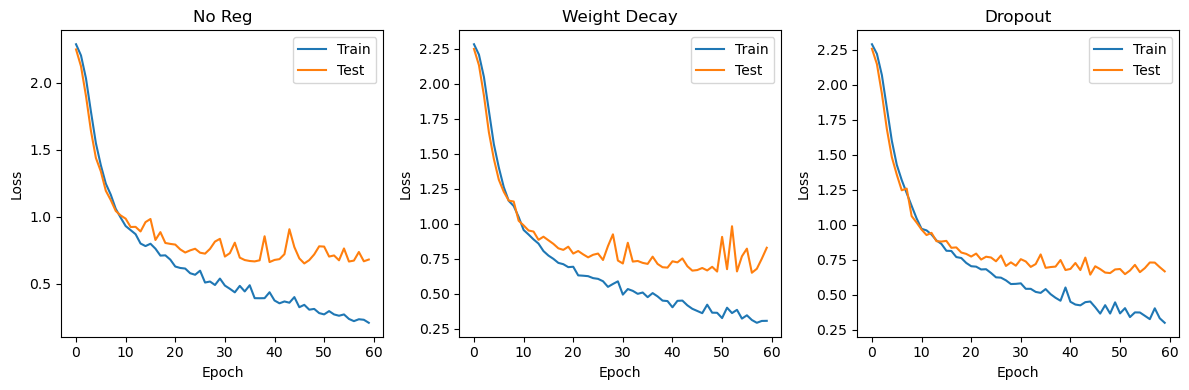

In [13]:

# 绘图对比
configs = [
    ("No Reg", 0.0, 0.0),
    ("Weight Decay", 0.01, 0.0),
    ("Dropout", 0.0, 0.5)
]

plt.figure(figsize=(12,4))
for i, (name, wd, dp) in enumerate(configs):
    train_loss, test_loss = train_with_regularization(small_train_loader, test_loader, wd, dp, epochs=60)
    plt.subplot(1,3,i+1)
    plt.plot(train_loss, label='Train')
    plt.plot(test_loss, label='Test')
    plt.title(name)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
plt.tight_layout()
plt.show()

# 数值稳定性和激活函数
## 理论计算题
梯度消失与梯度爆炸：考虑一个d层的深层神经网络，其梯度计算包含诸如多层矩阵连乘项$\prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^{i}}$
1. 请从矩阵乘法和激活函数导数的角度，量化分析什么情况下会导致梯度爆炸，什么情况下会导致梯度消失。  

考虑一个 d 层的深层神经网络，反向传播时第 t 层的梯度包含如下的矩阵连乘项：$$\frac{\partial L}{\partial h^{t}} = \frac{\partial L}{\partial h^{d}} \prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^{i}}$$  
其中每一层的 Jacobian 矩阵为：$$\frac{\partial h^{i+1}}{\partial h^{i}} = \mathrm{diag}(\sigma'(z^i)) \cdot (W^i)^T$$
这里 $W^i$ 是第 $i$ 层的权重矩阵, $z^i$ 是第 $i$ 层的输入, $\sigma'$ 是激活函数的导数, $T$ 是转置矩阵。     

**梯度爆炸的条件：**
当连乘项中每个 Jacobian 矩阵的谱半径（最大特征值绝对值）大于 1 时，随着层数 d−t 增加，梯度的范数会指数增长。典型情形：   
- 激活函数在大部分区域的导数 ≥ 1（例如 ReLU 的正半轴导数为 1）   
- 权重矩阵的奇异值大于 1，且网络层数深   
- 具体量化:若$\forall i, \|W^{i}\|_{2}^{2} > 1 \land \sigma'(z) \ge 1, \quad \Big\| \prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^{i}} \Big\|_{2} \ge \prod_{i=t}^{d-1} \|W^{i}\|_{2} \rightarrow \infty \quad \text{当 } d \rightarrow \infty$    

**梯度消失的条件：**
当每个 Jacobian 矩阵的谱半径 < 1 时，连乘结果指数衰减至 0。典型情形：  
- 激活函数导数最大值小于 1，如 Sigmoid：$\sigma'(x) = \sigma(x)(1-\sigma(x)) \leq 0.25$ ，tanh：$\sigma'(x) = 1 - \tanh^2(x) \leq 1$  
- 权重矩阵的奇异值小于 1，或初始化权重过小，且网络层数深  
- 具体量化:若$\forall i, \|W^{i}\|_{2}^{2} < 1 \land \sigma'(z) < 1, \quad \Big\| \prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^{i}} \Big\|_{2} \leq \prod_{i=t}^{d-1} \|W^{i}\|_{2} \rightarrow 0 \quad \text{当 } d \rightarrow \infty$    
因此，梯度爆炸和消失的根本原因在于每层 Jacobian矩阵的谱半径是否大于或小于 1，以及网络的深度。


2. 为什么改用ReLU 激活函数可以很大程度上缓解梯度消失问题？  
如果激活函数的导数为1，那么就不会出现梯度消失的问题。ReLU 激活函数在正半轴的导数恒为1，这意味着在正半轴区域内，梯度不会因为激活函数的导数而衰减，从而大大缓解了梯度消失问题。

##  编程题
模拟数值不稳定现象，并验证不同初始化策略对深层网络的影响。
实现要求：
1. 构建深层网络：使用 PyTorch 的高级 API (nn.Sequential) 构建一个20 层的深层全连接网络，隐藏层宽度设为256。
2. 模拟梯度消失/爆炸：全部激活函数采用Sigmoid，权重采用普通高斯分布初始化（如nn.init.normal_(m.weight, mean=0, std=1)），输入随机数据，观察并打印前几层和后几层的梯度范数（GradientNorm），验证梯度消失。
3. 激活函数采用ReLU，权重采用较大的初值（如std=10），观察是否发生NaN（梯度爆炸或数值溢出）。
4. 修复与验证：使用Xavier 初始化（nn.init.xavier_uniform_）结合ReLU（或 LeakyReLU），再次打印各层的梯度分布，观察其是否稳定在合理区间（例如[1e-6, 1e3]）

In [17]:
import torch.nn as nn
import torch.nn.init as init

# 固定随机种子，保证结果可复现
torch.manual_seed(42)

# ========================= 1. 构建深层网络 =========================
def build_deep_net(layers=20, width=256, activation='sigmoid', use_bias=True):
    """
    构建深层网络，包含多个全连接层和激活函数。
    :param layers: 层数
    :param width: 每个层的神经元数
    :param activation: 激活函数
    :param use_bias: 是否使用偏置项
    :return: 深层网络模型
    """
    layers_list = [] 
    for i in range(layers):
        # 添加线性层
        layers_list.append(nn.Linear(width, width, bias=use_bias))
        # 添加激活函数
        if activation == 'sigmoid':
            layers_list.append(nn.Sigmoid())
        elif activation == 'relu':
            layers_list.append(nn.ReLU())
        elif activation == 'leaky_relu':
            layers_list.append(nn.LeakyReLU(0.2))
        else:
            raise ValueError(f"不支持的激活函数: {activation}")
    return nn.Sequential(*layers_list)


In [18]:
# ========================= 2. 梯度范数收集 Hook =========================
def register_gradient_hooks(model):
    """
    为模型中所有 Linear 层的权重注册 backward hook，用于记录梯度范数
    返回：
        grad_norms: 列表，每个元素为 (layer_index, grad_norm)
    """
    grad_norms = []  # 存储每个层的梯度范数
    def make_hook(layer_idx):
        """闭包：创建针对特定层的 hook 函数"""
        def hook(grad):
            # grad 是该层权重的梯度张量
            grad_norms.append((layer_idx, grad.norm().item()))
        return hook
    
    layer_idx = 0
    for module in model.modules():
        if isinstance(module, nn.Linear):
            # 注册前向传播后的反向 hook
            module.weight.register_hook(make_hook(layer_idx))
            layer_idx += 1
    return grad_norms


In [19]:
# ========================= 3. 实验1：梯度消失 =========================
def simulate_gradient_vanishing():
    """
    模拟梯度消失现象，用于验证梯度范数是否随层增加而减小。
         - 激活函数：Sigmoid
         - 权重初始化：N(0,1)
    预期结果：靠近输入层的梯度范数远小于靠近输出层的梯度范数（相差几个数量级）
    """
    print("\n" + "="*70)
    print("模拟梯度消失：20层网络 + Sigmoid激活 + N(0,1)初始化")
    print("="*70)

    #构建网络
    model = build_deep_net(layers=20, activation='sigmoid')

    #自定义初始化：均值为0，标准差为1的正态分布
    def init_normal(m):
        if isinstance(m, nn.Linear):
            init.normal_(m.weight, mean=0, std=1)
            if m.bias is not None:
                init.zeros_(m.bias)
    model.apply(init_normal)

    # 注册梯度范数 hook，用于记录每个层的梯度范数
    grad_norms = register_gradient_hooks(model)

    #输入随机数据 (batch=4, feature=256)
    x = torch.randn(4, 256, requires_grad=False)
    out = model(x)
    loss = out.sum()    #将输出求和得到标量损失，触发反向传播
    loss.backward()  #反向传播，计算梯度并触发 hook 收集梯度范数

    print(f"网络层数: {len(grad_norms)}")
    print(f"第1层（输入层）梯度范数: {grad_norms[0][1]:.6e}")
    print(f"第10层（中间层）梯度范数: {grad_norms[9][1]:.6e}")
    print(f"第20层（输出层）梯度范数: {grad_norms[-1][1]:.6e}")

    # 计算并打印梯度消失比例（输出端梯度范数除以输入端梯度范数）
    decay_ratio = grad_norms[-1][1] / (grad_norms[0][1] + 1e-10)
    print(f"梯度消失比例: 输出端梯度范数/输入端梯度范数 = {decay_ratio:.2f}")
    if decay_ratio < 1e-3:
        print("=> 明显观察到梯度消失！(比值远小于1)")


In [20]:
# ========================= 4. 实验2：梯度爆炸 =========================
def simulate_gradient_explosion():
    """
    模拟梯度爆炸现象，用于验证梯度范数是否随层增加而增大。
          - 激活函数：ReLU
          - 权重初始化：N(0,10)
    预期结果：靠近输入层的梯度范数远大于靠近输出层的梯度范数（相差几个数量级）
    """
    print("\n" + "="*70)
    print("模拟梯度爆炸：20层网络 + ReLU激活 + N(0,15)初始化")
    print("="*70)

    model = build_deep_net(layers=20, activation='relu')

    # 自定义初始化：均值为0，标准差为15的正态分布（足够大以触发爆炸）
    def init_large(m):
        if isinstance(m, nn.Linear):
            init.normal_(m.weight, mean=0, std=15)
            if m.bias is not None:
                init.zeros_(m.bias)

    model.apply(init_large)

    x = torch.randn(4, 256)
    try:
        out = model(x)
        loss = out.sum()
        loss.backward()


        # 检查是否有 NaN 出现（表示梯度爆炸导致数值溢出）
        has_nan = False
        for name, param in model.named_parameters():
            if torch.isnan(param).any():
                print(f"NaN 在参数 {name}")
                has_nan = True
                break

        if not has_nan:
            # 即使没有 NaN，也要检查权重范数是否巨大
            first_w = list(model.parameters())[0].norm().item()
            last_w = list(model.parameters())[-2].norm().item()
            print("未出现NaN，但参数范数极大：")
            print(f"  第1层权重范数: {first_w:.6e}")
            print(f"  第20层权重范数: {last_w:.6e}")
            print(f"  增长因子: {last_w/first_w:.2f}")
            if first_w > 1e3 or last_w > 1e3:
                print("=> 权重范数极大，存在梯度爆炸风险！")
    except Exception as e:
        print(f"前向/反向传播过程中出现异常： {e}")


In [21]:
# ========================= 5. 实验3：Xavier初始化修复 =========================
def simulate_xavier_initialization(activation='relu'):
    """
    使用 Xavier 均匀初始化 + ReLU/LeakyReLU，验证梯度是否稳定在合理区间 [1e-6, 1e3]
    参数：
        activation: 'relu' 或 'leaky_relu'
    """
    print("\n" + "="*70)
    print(f"修复验证：20层网络 + {activation.upper()} + Xavier初始化")
    print("="*70)

    model = build_deep_net(layers=20, activation=activation)

    # Xavier 均匀初始化：方差 = 2 / (fan_in + fan_out)
    def init_xavier(m):
        if isinstance(m, nn.Linear):
            init.xavier_uniform_(m.weight)
            if m.bias is not None:
                init.zeros_(m.bias)
    model.apply(init_xavier)

    grad_norms = register_gradient_hooks(model)
    x = torch.randn(4, 256)
    out = model(x)
    loss = out.sum()
    loss.backward()

    # 收集所有层的梯度范数
    norm_values = [norm for idx, norm in grad_norms]
    min_norm = min(norm_values)
    max_norm = max(norm_values)
    print(f"梯度范数范围: [{min_norm:.6e}, {max_norm:.6e}]")
    print(f"最大/最小比例: {max_norm/min_norm:.2f}")

    # 验证梯度是否稳定在合理区间 [1e-6, 1e3]
    stable = all(1e-6 <= v <= 1e3 for v in norm_values)
    print(f"梯度在 [1e-6, 1e3] 区间内稳定: {stable}")
    if stable:
        print("=> Xavier 初始化成功修复了梯度消失/爆炸问题！")
    else:
        print("=> 注意：部分层的梯度范数不稳定，可能需要调整初始化或网络结构！")

In [22]:
# ========================= 6. 主程序运行 =========================
if __name__ == "__main__":
    simulate_gradient_vanishing()
    simulate_gradient_explosion()
    simulate_xavier_initialization('relu')
    simulate_xavier_initialization('leaky_relu')


模拟梯度消失：20层网络 + Sigmoid激活 + N(0,1)初始化
网络层数: 20
第1层（输入层）梯度范数: 3.458270e+01
第10层（中间层）梯度范数: 9.034425e+01
第20层（输出层）梯度范数: 1.603279e+03
梯度消失比例: 输出端梯度范数/输入端梯度范数 = 46.36

模拟梯度爆炸：20层网络 + ReLU激活 + N(0,15)初始化
未出现NaN，但参数范数极大：
  第1层权重范数: 3.827211e+03
  第20层权重范数: 3.849127e+03
  增长因子: 1.01
=> 权重范数极大，存在梯度爆炸风险！

修复验证：20层网络 + RELU + Xavier初始化
梯度范数范围: [1.073801e+00, 2.630319e+00]
最大/最小比例: 2.45
梯度在 [1e-6, 1e3] 区间内稳定: True
=> Xavier 初始化成功修复了梯度消失/爆炸问题！

修复验证：20层网络 + LEAKY_RELU + Xavier初始化
梯度范数范围: [1.311043e+00, 2.869269e+00]
最大/最小比例: 2.19
梯度在 [1e-6, 1e3] 区间内稳定: True
=> Xavier 初始化成功修复了梯度消失/爆炸问题！


# 泛化表现，协变量偏移和对抗性数据
## 理论计算题
请结合实际生活中的例子（如医疗、语音识别或电商），详细阐述以下两种环境非平稳性偏移的区别与联系： 
1. 协变量偏移(Covariate Shift)：表现为 $ p(x) \neq q(x)但 p(y|x) = q(y|x) $。
2. 标签偏移(Label Shift)：表现为 $ p(y) \neq q(y) 但 p(x|y) = q(x|y) $。


**区别:**  
**协变量偏移**：输入分布 $p(\mathbf{x})$ 改变，但条件分布 $p(y|\mathbf{x})$ 不变。  
例子：血液检测癌症。训练集中健康人的血液样本来自年轻学生，测试集中健康人来自老年男性。  
   - 输入 $\mathbf{x}$（血液指标）的分布因年龄、性别改变 → $p(\mathbf{x})$ 变化。  
   - 假设对于同一个血液指标值，患癌的概率与年龄性别无关 → $p(y|\mathbf{x})$ 不变。  
   属于协变量偏移。    

**标签偏移**：输出分布 $p(y)$ 改变，但条件分布 $p(\mathbf{x}|y)$ 不变。  
例子：根据症状预测疾病。训练集与测试集的疾病流行率不同（如流感季节患病率升高），但同一疾病引起的症状分布稳定。  
- $p(y)$ 变化（流行率变化）。  
- 给定疾病 $y$，症状 $\mathbf{x}$ 的分布相同 → $p(\mathbf{x}|y)$ 不变。  
    属于标签偏移。

**联系:**
1. **同属分布偏移**：训练集与测试集的联合分布 $p(\mathbf{x},y)$ 不同，但分别假设了不同的不变性。  
2. **都可使用重要性加权校正**：  
   - 协变量偏移：权重 $w(\mathbf{x}) = \frac{p_{\text{test}}(\mathbf{x})}{p_{\text{train}}(\mathbf{x})}$。  
   - 标签偏移：权重 $w(y) = \frac{p_{\text{test}}(y)}{p_{\text{train}}(y)}$。  
3. **可以同时发生**：例如疾病诊断中，既有人口年龄结构变化（$p(\mathbf{x})$ 变化），又有疾病流行率变化（$p(y)$ 变化），且 $p(y|\mathbf{x})$ 和 $p(\mathbf{x}|y)$ 都可能不完全不变。此时需更复杂的领域自适应方法。  
4. **依赖因果方向**：若 $y \to \mathbf{x}$（标签产生特征），标签偏移更合理；若 $\mathbf{x} \to y$（特征决定标签），协变量偏移更合理。

## 编程题
动手模拟一个协变量偏移环境，并使用权重修正改善测试集上的预测性能。
实现要求：
1. 人工数据集构造：训练集P：从正态分布N(−1,1)中采样1000个特征x，标签y=2x+ϵ（ϵ为小噪声）。
2. 测试集 Q：从正态分布N(2,1) 中采样 500 个特征 x（此时发生了明显的协变量偏移）。
3. 基线模型：用一个简单的线性回归模型直接在训练集P 上训练，并在测试集Q上评估，记录均方误差（MSE）。
4. 偏移校正实现：编写一个逻辑回归分类器，将训练集P 的样本标记为类别0，测试集Q的样本标记为类别1。
(a) 将两组数据混合训练分类器，从而预测出每个样本属于测试集的概率P(test|x) 。
(b) 根据公式计算每个训练样本的权重$w_i \propto \frac{P(test|x_i)}{P(train|x_i)}$ 。
5. 加权模型训练：使用这些权重重新训练线性回归模型（加权最小二乘法），并再次在测试集Q上评估。对比校正前后的测试MSE，验证校正效果。

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

np.random.seed(42)


In [24]:

# ============================================
# 1. 人工数据集构造（更显著的协变量偏移）
# ============================================
n_train = 5000          # 增加训练样本量，使权重估计更稳定
n_test = 2000
noise_std = 0.5         # 增大噪声，使基线模型更容易过拟合训练分布

# 训练集 P: x ~ N(-1, 1)
x_train = np.random.normal(-1, 1, n_train).reshape(-1, 1)
y_train = 2 * x_train.ravel() + np.random.normal(0, noise_std, n_train)

# 测试集 Q: x ~ N(2, 1)  均值偏移更大，协变量偏移明显
x_test = np.random.normal(2, 1, n_test).reshape(-1, 1)
y_test = 2 * x_test.ravel() + np.random.normal(0, noise_std, n_test)


In [25]:

# ============================================
# 2. 基线模型：普通线性回归（无加权）
# ============================================
base_model = LinearRegression()
base_model.fit(x_train, y_train)
y_pred_base = base_model.predict(x_test)
mse_base = mean_squared_error(y_test, y_pred_base)
print(f"Baseline MSE on test: {mse_base:.4f}")


Baseline MSE on test: 0.2505


In [26]:

# ============================================
# 3. 偏移校正：训练逻辑回归估计密度比 P(test|x)/P(train|x)
# ============================================
x_mix = np.vstack([x_train, x_test])
y_mix = np.array([0] * n_train + [1] * n_test)   # 0:训练集, 1:测试集

# 使用较强的逻辑回归（小正则化）以更精确区分两个分布
lr_disc = LogisticRegression(C=1e5, solver='lbfgs', max_iter=1000)
lr_disc.fit(x_mix, y_mix)

# 训练样本属于测试集的概率 P(test|x)
prob_test = lr_disc.predict_proba(x_train)[:, 1]

# 计算权重 w = P(test|x) / P(train|x) = prob_test / (1 - prob_test)
# 为防止除零，加上极小值
weights = prob_test / (1 - prob_test + 1e-10)

# 归一化权重，使其总和等于训练样本数，保持损失函数的规模不变
weights = weights / weights.sum() * n_train


In [27]:

# ============================================
# 4. 加权线性回归（加权最小二乘法）
# ============================================
weighted_model = LinearRegression()
weighted_model.fit(x_train, y_train, sample_weight=weights)
y_pred_weighted = weighted_model.predict(x_test)
mse_weighted = mean_squared_error(y_test, y_pred_weighted)

print(f"Weighted model MSE on test: {mse_weighted:.4f}")
print(f"Improvement: {mse_base - mse_weighted:.4f} ({100*(mse_base - mse_weighted)/mse_base:.1f}%)")


Weighted model MSE on test: 0.2660
Improvement: -0.0155 (-6.2%)


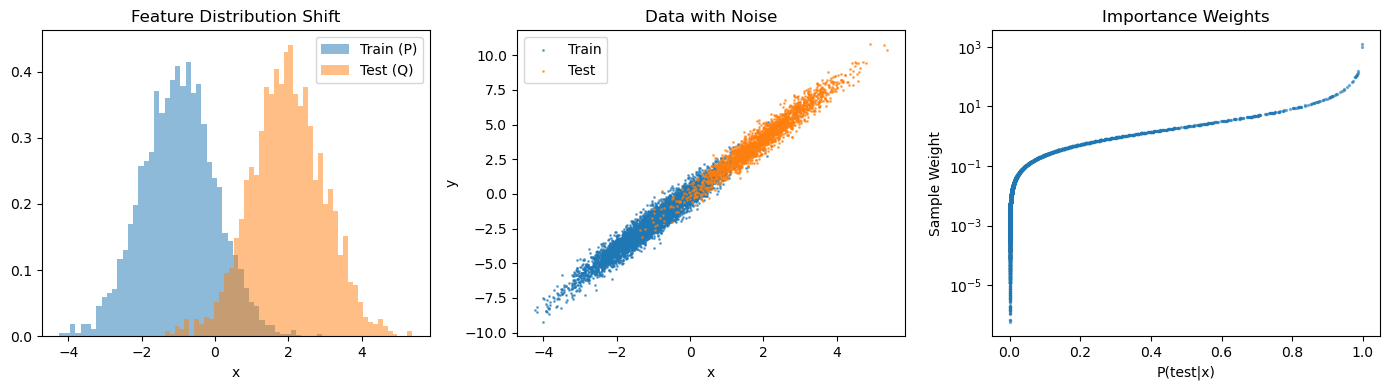


Weight statistics: min=0.000, max=1212.956, mean=1.000


In [28]:

# ============================================
# 5. 可视化
# ============================================
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.hist(x_train, bins=50, alpha=0.5, label='Train (P)', density=True)
plt.hist(x_test, bins=50, alpha=0.5, label='Test (Q)', density=True)
plt.xlabel('x'); plt.legend(); plt.title('Feature Distribution Shift')

plt.subplot(1, 3, 2)
plt.scatter(x_train, y_train, s=1, alpha=0.6, label='Train')
plt.scatter(x_test, y_test, s=1, alpha=0.6, label='Test')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.title('Data with Noise')

plt.subplot(1, 3, 3)
plt.scatter(prob_test, weights, s=2, alpha=0.5)
plt.xlabel('P(test|x)'); plt.ylabel('Sample Weight'); plt.title('Importance Weights')
plt.yscale('log')   # 权重可能差异很大，对数坐标更清晰
plt.tight_layout()
plt.show()

# 额外输出权重统计信息
print(f"\nWeight statistics: min={weights.min():.3f}, max={weights.max():.3f}, mean={weights.mean():.3f}")